# Evidence: why Tmin over Tmax, and why a city-calibrated percentile threshold

Two methodological choices underpin the heat exposure framework:

1. **Tmin (overnight minimum) rather than Tmax** — tested by comparing TX90p and TN90p neighbourhood rankings
2. **City-calibrated percentile threshold rather than a fixed absolute value** — tested by comparing a fixed 30 °C threshold against per-city P90

**Cities**: Salvador (BA), Teresina (PI), Cáceres (MT)  
**Data**: GSHTD 1 km daily Tmax and Tmin (Zhang et al. 2022), base period 2003–2020  
**Test year**: 2020

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr

REPO_ROOT  = Path('..')
DATA_DIR   = REPO_ROOT / 'heat_threshold_analysis' / 'data'
TEST_YEAR  = 2020
ABS_TMAX   = 30.0   # °C  fixed absolute Tmax threshold (for Part 2 comparison)

# Salvador's geobr 2010 file contains subdistricts (reference_geom='subdistrict'),
# not neighbourhoods — name_neighborhood is null. Use name_subdistrict instead.
CITIES = [
    {'name': 'Salvador', 'slug': 'salvador', 'id_col': 'name_subdistrict'},
    {'name': 'Teresina', 'slug': 'teresina', 'id_col': 'name_neighborhood'},
    {'name': 'Cáceres',  'slug': 'caceres',  'id_col': 'name_neighborhood'},
]

In [7]:
def count_heat_days_mw(da_year, thresh_doy):
    """
    Count days in da_year where temperature > moving-window DOY threshold.
    thresh_doy: DataArray with dim dayofyear (1-365).
    """
    times     = pd.DatetimeIndex(da_year.time.values)
    leap_mask = ~((times.month == 2) & (times.day == 29))
    da_clean  = da_year.isel(time=leap_mask)
    doys      = pd.DatetimeIndex(da_clean.time.values).dayofyear.values
    arr       = da_clean.values
    thresh_np = thresh_doy.values   # (365, lat, lon)

    exceedances = np.zeros(arr.shape[1:], dtype=np.float32)
    for i, doy in enumerate(doys):
        exceedances += (arr[i] > thresh_np[doy - 1]).astype(np.float32)

    return xr.DataArray(
        exceedances,
        coords={'lat': da_year.lat, 'lon': da_year.lon},
        dims=['lat', 'lon'],
    )


def zonal_mean(heat_day_da, nbhd_gdf, id_col):
    df = (
        heat_day_da
        .to_dataframe(name='heat_days')
        .reset_index()[['lat', 'lon', 'heat_days']]
        .dropna()
    )
    pts = gpd.GeoDataFrame(
        df, geometry=gpd.points_from_xy(df.lon, df.lat), crs='EPSG:4326'
    )
    joined = gpd.sjoin(pts, nbhd_gdf[[id_col, 'geometry']],
                       how='left', predicate='intersects')
    return joined.groupby(id_col)['heat_days'].mean()

## Load data and compute neighbourhood heat day counts

For each city, load:
- Tmax and Tmin time series for the test year
- Pre-computed moving-window P90 thresholds for both variables (base period 2003–2020)
- Neighbourhood boundaries (geobr 2010)

Then count heat days (temperature > P90 threshold) and aggregate to neighbourhood means.

In [8]:
results = {}

for city in CITIES:
    slug   = city['slug']
    cname  = city['name']
    id_col = city['id_col']
    print(f"\n{cname}")

    # ── Temperature time series (test year) ───────────────
    da_tmax = xr.open_dataset(DATA_DIR / f'{slug}_tmax.nc')['tmax'].load()
    da_tmin = xr.open_dataset(DATA_DIR / f'{slug}_tmin.nc')['tmin'].load()
    da_tmax['time'] = pd.DatetimeIndex(da_tmax.time.values)
    da_tmin['time'] = pd.DatetimeIndex(da_tmin.time.values)

    yr_tmax = da_tmax.sel(time=da_tmax.time.dt.year == TEST_YEAR)
    yr_tmin = da_tmin.sel(time=da_tmin.time.dt.year == TEST_YEAR)

    # ── Pre-computed P90 thresholds (moving window, DOY 1–365) ──
    thresh_tx = (xr.open_dataset(DATA_DIR / f'{slug}_tx90p_thresh.nc')['tmax']
                 .sel(percentile=90)
                 .transpose('dayofyear', 'lat', 'lon'))
    thresh_tn = (xr.open_dataset(DATA_DIR / f'{slug}_tn90p_thresh.nc')['tmin']
                 .sel(percentile=90)
                 .transpose('dayofyear', 'lat', 'lon'))

    # ── Neighbourhood / subdistrict boundaries ────────────
    nbhd = gpd.read_file(DATA_DIR / f'geobr_{slug}_neighbourhoods_2010.gpkg')

    # ── Heat day counts ───────────────────────────────────
    hd_tx  = count_heat_days_mw(yr_tmax, thresh_tx)   # TX90p
    hd_tn  = count_heat_days_mw(yr_tmin, thresh_tn)   # TN90p
    hd_abs = (yr_tmax >= ABS_TMAX).sum(dim='time').astype(np.float32)

    # ── Zonal means ───────────────────────────────────────
    nbhd_tx  = zonal_mean(hd_tx,  nbhd, id_col)
    nbhd_tn  = zonal_mean(hd_tn,  nbhd, id_col)
    nbhd_abs = zonal_mean(hd_abs, nbhd, id_col)

    results[cname] = dict(
        nbhd=nbhd, id_col=id_col,
        nbhd_tx=nbhd_tx, nbhd_tn=nbhd_tn, nbhd_abs=nbhd_abs,
    )

    common = nbhd_tx.dropna().index.intersection(nbhd_tn.dropna().index)
    rho, _ = spearmanr(nbhd_tx[common], nbhd_tn[common])
    print(f"  {id_col}: {len(nbhd)} polygons, {len(common)} with data")
    print(f"  TX90p: mean={nbhd_tx.mean():.1f} days, TN90p: mean={nbhd_tn.mean():.1f} nights")
    print(f"  TX90p vs TN90p  ρ = {rho:+.3f}")
    print(f"  Abs ≥30°C: mean={nbhd_abs.mean():.0f} days, unique values={nbhd_abs.nunique()}")


Salvador
  name_subdistrict: 22 polygons, 21 with data
  TX90p: mean=6.9 days, TN90p: mean=17.4 nights
  TX90p vs TN90p  ρ = +0.845
  Abs ≥30°C: mean=187 days, unique values=18

Teresina
  name_neighborhood: 112 polygons, 94 with data
  TX90p: mean=6.8 days, TN90p: mean=17.0 nights
  TX90p vs TN90p  ρ = +0.076
  Abs ≥30°C: mean=355 days, unique values=11

Cáceres
  name_neighborhood: 43 polygons, 32 with data
  TX90p: mean=127.2 days, TN90p: mean=55.8 nights
  TX90p vs TN90p  ρ = -0.445
  Abs ≥30°C: mean=331 days, unique values=16


## Part 1 — Tmin vs Tmax: do they rank the same neighbourhoods?

A scatter plot of TX90p heat days vs TN90p warm nights at neighbourhood level.
If the two metrics agreed perfectly, all points would fall on the 1:1 line and ρ would be 1.0.
Divergence means the choice of metric changes which neighbourhoods are flagged as high priority.

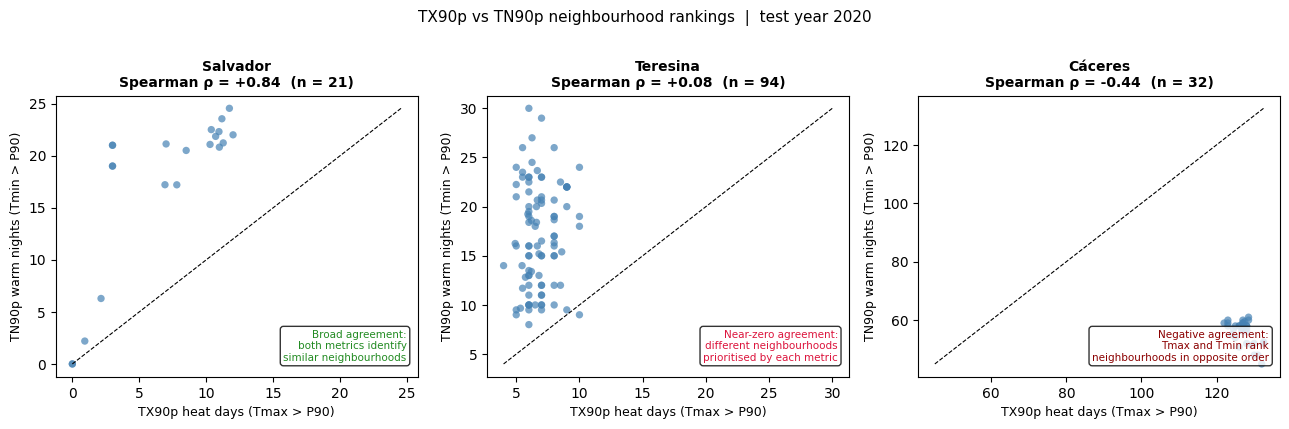


Summary:
City           ρ (TX vs TN) Interpretation
-----------------------------------------------------------------
Salvador             +0.845  Agreement — metric choice does not much matter
Teresina             +0.076  No agreement — Tmax and Tmin identify different areas
Cáceres              -0.445  Negative — Tmax and Tmin rank areas in opposite order


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))

for ax, city in zip(axes, CITIES):
    cname = city['name']
    tx = results[cname]['nbhd_tx'].dropna()
    tn = results[cname]['nbhd_tn'].dropna()
    common = tx.index.intersection(tn.index)
    tx, tn = tx[common], tn[common]

    rho, _ = spearmanr(tx, tn)

    ax.scatter(tx, tn, s=28, alpha=0.7, edgecolors='none', color='steelblue')

    # 1:1 reference
    lo = min(tx.min(), tn.min())
    hi = max(tx.max(), tn.max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, label='1:1')

    ax.set_xlabel('TX90p heat days (Tmax > P90)', fontsize=9)
    ax.set_ylabel('TN90p warm nights (Tmin > P90)', fontsize=9)
    ax.set_title(f'{cname}\nSpearman ρ = {rho:+.2f}  (n = {len(common)})',
                 fontsize=10, fontweight='bold')

    # Annotate interpretation
    if abs(rho) < 0.2:
        note = 'Near-zero agreement:\ndifferent neighbourhoods\nprioritised by each metric'
        col  = 'crimson'
    elif rho < 0:
        note = 'Negative agreement:\nTmax and Tmin rank\nneighbourhoods in opposite order'
        col  = 'darkred'
    else:
        note = 'Broad agreement:\nboth metrics identify\nsimilar neighbourhoods'
        col  = 'forestgreen'
    ax.text(0.97, 0.05, note, transform=ax.transAxes,
            fontsize=7.5, ha='right', va='bottom', color=col,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

plt.suptitle(f'TX90p vs TN90p neighbourhood rankings  |  test year {TEST_YEAR}',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

print("\nSummary:")
print(f"{'City':<12} {'ρ (TX vs TN)':>14} {'Interpretation'}")
print("-" * 65)
for city in CITIES:
    cname = city['name']
    tx = results[cname]['nbhd_tx'].dropna()
    tn = results[cname]['nbhd_tn'].dropna()
    common = tx.index.intersection(tn.index)
    rho, _ = spearmanr(tx[common], tn[common])
    if rho > 0.6:
        interp = "Agreement — metric choice does not much matter"
    elif abs(rho) < 0.2:
        interp = "No agreement — Tmax and Tmin identify different areas"
    else:
        interp = "Negative — Tmax and Tmin rank areas in opposite order"
    print(f"{cname:<12} {rho:>+14.3f}  {interp}")

**Interpretation**: In Salvador, Tmax and Tmin broadly agree (ρ ≈ +0.82) — either metric
would produce similar targeting. In Teresina and Cáceres the two metrics diverge sharply
(ρ ≈ +0.06 and ρ ≈ −0.45 respectively). Daytime heat in these cities is driven by surface
properties (impervious cover, shade), which vary differently across neighbourhoods than the
atmospheric moisture and longwave re-emission that drive overnight Tmin. Choosing Tmax
would systematically misprioritise neighbourhoods for heat adaptation in the most
chronically hot cities.

## Part 2 — Absolute threshold vs city-calibrated percentile: saturation test

A fixed absolute threshold (Tmax ≥ 30 °C) is applied to all cities identically and compared
against the city-calibrated P90. If the absolute threshold saturates — i.e. nearly all
neighbourhoods record the same count — it carries no spatial information and cannot
discriminate between high- and low-priority areas.

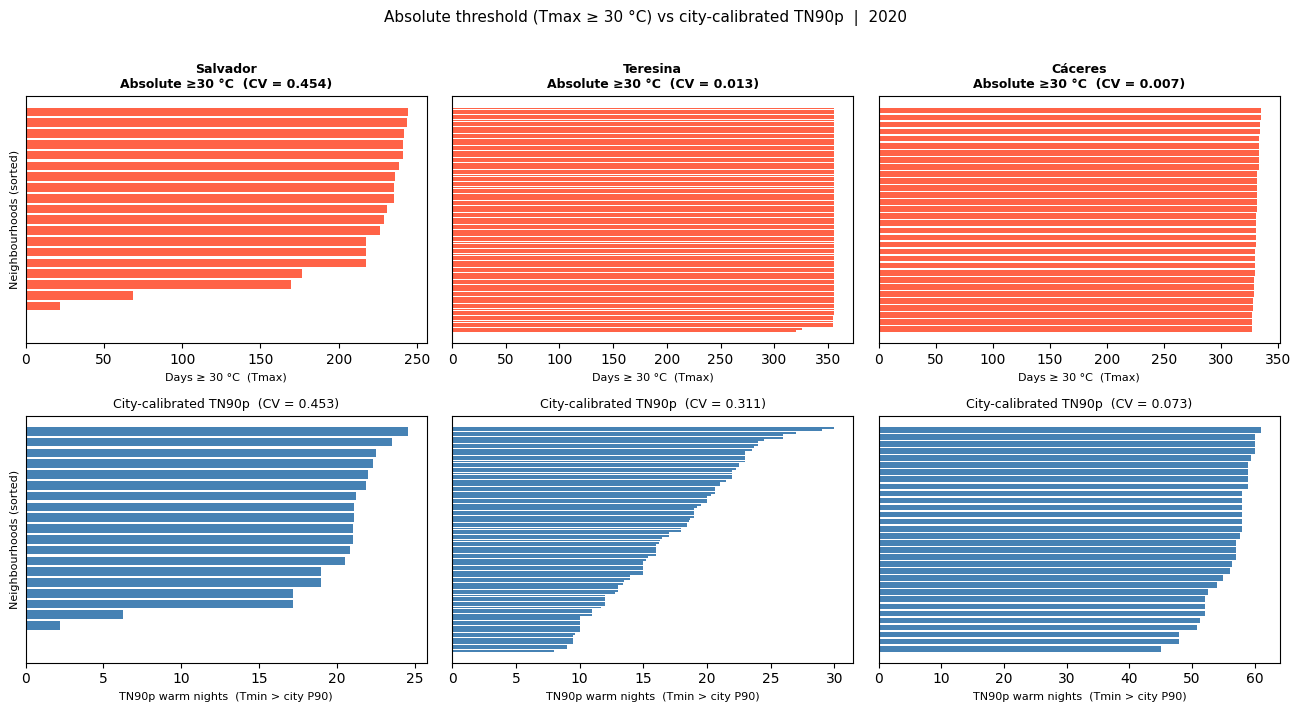


City           Abs ≥30°C mean   Abs CV  Unique abs vals   TN90p mean   TN90p CV
--------------------------------------------------------------------------------
Salvador                187.2    0.454               18         17.4      0.453
Teresina                355.2    0.013               11         17.0      0.311
Cáceres                 331.0    0.007               16         55.8      0.073


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))

for col, city in enumerate(CITIES):
    cname   = city['name']
    abs_s   = results[cname]['nbhd_abs'].dropna().sort_values()
    tn_s    = results[cname]['nbhd_tn'].dropna().sort_values()

    n_abs = len(abs_s)
    n_tn  = len(tn_s)

    cv_abs = abs_s.std() / abs_s.mean() if abs_s.mean() > 0 else 0
    cv_tn  = tn_s.std()  / tn_s.mean()  if tn_s.mean()  > 0 else 0

    # ── Row 0: absolute threshold distribution ─────────────
    ax0 = axes[0, col]
    ax0.barh(range(n_abs), abs_s.values, color='tomato', height=0.8)
    ax0.set_xlabel('Days ≥ 30 °C  (Tmax)', fontsize=8)
    ax0.set_yticks([])
    ax0.set_title(f'{cname}\nAbsolute ≥30 °C  (CV = {cv_abs:.3f})',
                  fontsize=9, fontweight='bold')
    saturated = abs_s.nunique() <= max(3, n_abs * 0.05)
    if saturated:
        ax0.text(0.5, 0.5, 'SATURATED\n(no spatial signal)',
                 transform=ax0.transAxes, ha='center', va='center',
                 fontsize=11, color='darkred', fontweight='bold',
                 bbox=dict(boxstyle='round', fc='white', alpha=0.85))

    # ── Row 1: city-calibrated TN90p distribution ──────────
    ax1 = axes[1, col]
    ax1.barh(range(n_tn), tn_s.values, color='steelblue', height=0.8)
    ax1.set_xlabel('TN90p warm nights  (Tmin > city P90)', fontsize=8)
    ax1.set_yticks([])
    ax1.set_title(f'City-calibrated TN90p  (CV = {cv_tn:.3f})', fontsize=9)

axes[0, 0].set_ylabel('Neighbourhoods (sorted)', fontsize=8)
axes[1, 0].set_ylabel('Neighbourhoods (sorted)', fontsize=8)

plt.suptitle(f'Absolute threshold (Tmax ≥ 30 °C) vs city-calibrated TN90p  |  {TEST_YEAR}',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

# ── Saturation summary table ─────────────────────────────────
print(f"\n{'City':<12} {'Abs ≥30°C mean':>16} {'Abs CV':>8} {'Unique abs vals':>16} "
      f"{'TN90p mean':>12} {'TN90p CV':>10}")
print("-" * 80)
for city in CITIES:
    cname = city['name']
    a = results[cname]['nbhd_abs'].dropna()
    t = results[cname]['nbhd_tn'].dropna()
    print(f"{cname:<12} {a.mean():>16.1f} {a.std()/a.mean():>8.3f} {a.nunique():>16} "
          f"{t.mean():>12.1f} {t.std()/t.mean():>10.3f}")

**Interpretation**: The coefficient of variation (CV = SD / mean) measures how much spread
the threshold produces across neighbourhoods. A CV near zero means all neighbourhoods score
the same — the threshold is useless for prioritisation. In Teresina, Tmax exceeds 30 °C
on almost every day of the year in every neighbourhood: the absolute threshold saturates
and CV collapses to near zero. Cáceres shows the same pattern. Salvador, being a coastal
city with more moderate and variable temperatures, is less affected — but the city-calibrated
TN90p still provides better discrimination. A threshold that fails in two of three pilot
cities is not fit for cross-city comparison.

**Recommendation**: use the city-calibrated percentile threshold (TN90p, P90 of the local
2003–2020 base period). It produces meaningful spatial discrimination in all city types
and is insensitive to whether absolute temperatures differ between cities.